# Hard coal+CCS NPV simulation

Run the hard coal+CCS electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity.electricity_npv_monte_carlo import simulate_hard_coal_ccs_npv


In [2]:
SAMPLE_SIZE = 1000000
#RANDOM_SEED = 42

rng = np.random.default_rng() 
simulation = simulate_hard_coal_ccs_npv(size=SAMPLE_SIZE, rng=rng)
results = pd.DataFrame(simulation)

results.head()

,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,hard_coal_ccs,1000000.0,4100.0,243.902439,243902.439024,4855.382376,81.607421,11.273518,3.223056,...,94070000.0,1.990425e+07,1.127352e+07,4.340146e+07,4.992471e+06,1.449830e+07,-1.029474e+09,25000000.0,-41.178941,-0.000041
1,1,hard_coal_ccs,1000000.0,4100.0,243.902439,243902.439024,3172.874596,110.030560,13.144958,3.204204,...,94070000.0,2.683672e+07,1.314496e+07,3.461575e+07,2.432230e+06,1.704034e+07,-5.919700e+08,25000000.0,-23.678801,-0.000024
2,2,hard_coal_ccs,1000000.0,4100.0,243.902439,243902.439024,4150.475270,86.953897,10.105477,3.112292,...,94070000.0,2.120827e+07,1.010548e+07,4.744565e+07,5.886757e+06,9.423849e+06,-9.117136e+08,25000000.0,-36.468542,-0.000036
3,3,hard_coal_ccs,1000000.0,4100.0,243.902439,243902.439024,4844.337465,78.748313,10.417640,3.091373,...,94070000.0,1.920691e+07,1.041764e+07,3.931979e+07,4.036127e+06,2.108954e+07,-9.564196e+08,25000000.0,-38.256783,-0.000038
4,4,hard_coal_ccs,1000000.0,4100.0,243.902439,243902.439024,4554.021484,79.698388,10.588480,3.181207,...,94070000.0,1.943863e+07,1.058848e+07,3.879020e+07,7.622273e+06,1.763042e+07,-9.225362e+08,25000000.0,-36.901448,-0.000037


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
npv_million_eur_per_mwh = results["npv_million_eur_per_mwh"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
        npv_million_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh,NPV million EUR/MWh
count,1000000.000000,1000000.000000,1000000.000000
mean,-795.527674,-31.821107,-0.000032
std,172.640847,6.905634,0.000007
min,-1456.696617,-58.267865,-0.000058
5%,-1076.156951,-43.046278,-0.000043
50%,-795.316076,-31.812643,-0.000032
95%,-519.090790,-20.763632,-0.000021
max,-299.095001,-11.963800,-0.000012


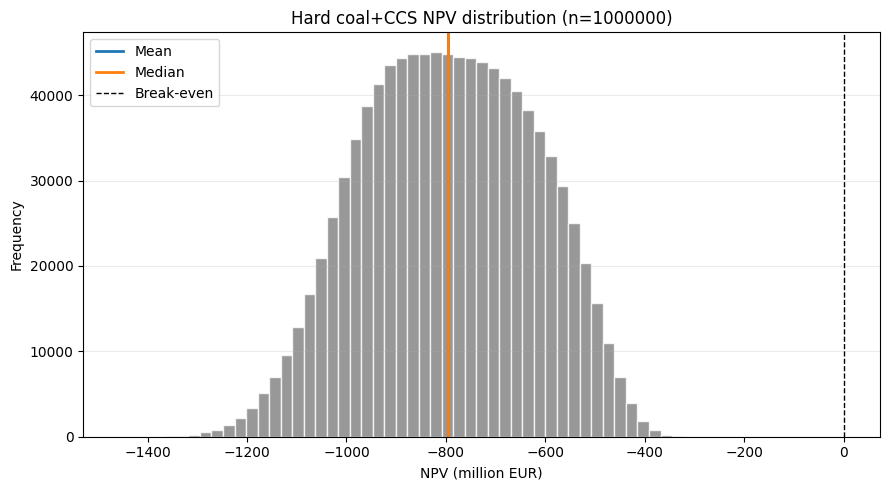

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Hard coal+CCS NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

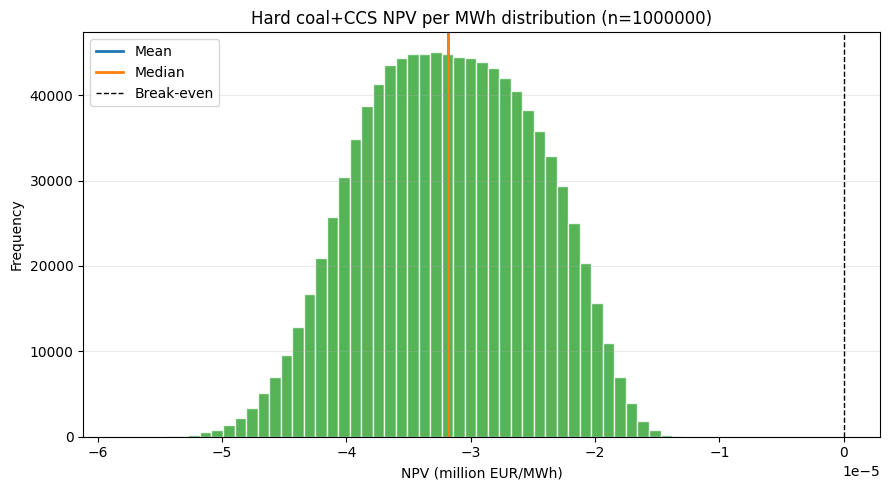

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_million_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_million_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_million_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Hard coal+CCS NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur        21.092092
annual_variable_opex_eur     11.278330
annual_fuel_cost_eur         38.285031
annual_emissions_cost_eur     4.799241
annual_net_cash_flow_eur     18.615305
Name: Mean annual value, million EUR, dtype: float64